<a href="https://colab.research.google.com/github/viunadyapage/23142_Nadya_Praktikum_tugas-/blob/main/Analisis_Sentimen_Timnas_STY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Instalasi dan Impor Library

Bagian ini melakukan instalasi library yang diperlukan untuk pemrosesan teks dan analisis sentimen, serta mengimpor modul Python yang akan digunakan sepanjang notebook.

In [1]:
!pip -q install Sastrawi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
from collections import Counter

# 2. Load Dataset

Dataset komentar Timnas Indonesia akan dimuat dari Google Drive ke dalam Pandas DataFrame untuk analisis lebih lanjut.

In [3]:
url = "https://drive.google.com/uc?id=1rdz1Sck0PcFRyYpb1xvK1LrAC_pUZePa"
df = pd.read_csv(url, sep=';')

df.head()

,id,date,platform,username,text,sentiment
0,1,03/04/2026,X,user_6688,@PSSI STY memberi identitas permainan yang jel...,positif
1,3,19/04/2026,X,user_7920,Saya kecewa karena finishing Timnas masih lema...,negatif
2,4,11/04/2026,X,user_1815,Bangga lihat Timnas main berani lawan tim besa...,positif
3,5,24/04/2026,X,user_3200,"Strategi STY hari ini kurang efektif, serangan...",negatif
4,6,11/04/2026,X,user_8170,Kemenangan ini bukti Timnas punya masa depan c...,positif


# 3. Cek Dataset

Pemeriksaan awal dataset meliputi bentuk data (shape), informasi kolom (info), jumlah data duplikat, dan distribusi label sentimen untuk memahami karakteristik data.

In [4]:
# Tampilkan bentuk dataset (jumlah baris, jumlah kolom)
print("Bentuk dataset (baris, kolom):", df.shape)

# Tampilkan informasi dataset (tipe data, non-null counts)
print("\nInformasi Dataset:")
df.info()

# Tampilkan jumlah data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# Tampilkan distribusi sentimen
print("\nDistribusi Sentimen:")
print(df['sentiment'].value_counts())

Bentuk dataset (baris, kolom): (179, 6)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         179 non-null    int64 
 1   date       179 non-null    object
 2   platform   179 non-null    object
 3   username   179 non-null    object
 4   text       179 non-null    object
 5   sentiment  179 non-null    object
dtypes: int64(1), object(5)
memory usage: 8.5+ KB

Jumlah data duplikat: 0

Distribusi Sentimen:
sentiment
positif    93
negatif    86
Name: count, dtype: int64


# 4. Text Preprocessing

Tahap ini bertujuan untuk membersihkan teks dari karakter yang tidak relevan dan mengubahnya ke format standar agar siap untuk analisis. Langkah-langkahnya meliputi *case folding*, *cleaning*, *tokenization*, *stopword removal*, dan *stemming*.

### Menentukan Kolom Teks

In [5]:
if 'komentar' in df.columns:
    text_column = 'komentar'
elif 'text' in df.columns:
    text_column = 'text'
elif 'ulasan' in df.columns:
    text_column = 'ulasan'
else:
    raise ValueError("Kolom teks tidak ditemukan")

### Case Folding

In [6]:
def case_folding(text):
    text = text.lower()
    return text

df['case_folding'] = df[text_column].apply(case_folding)

df[['text', 'case_folding']].head()

,text,case_folding
0,@PSSI STY memberi identitas permainan yang jel...,@pssi sty memberi identitas permainan yang jel...
1,Saya kecewa karena finishing Timnas masih lema...,saya kecewa karena finishing timnas masih lema...
2,Bangga lihat Timnas main berani lawan tim besa...,bangga lihat timnas main berani lawan tim besa...
3,"Strategi STY hari ini kurang efektif, serangan...","strategi sty hari ini kurang efektif, serangan..."
4,Kemenangan ini bukti Timnas punya masa depan c...,kemenangan ini bukti timnas punya masa depan c...


### Cleaning

In [7]:
def cleaning(text):
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

df['cleaning'] = df['case_folding'].apply(cleaning)

df[['case_folding', 'cleaning']].head()

,case_folding,cleaning
0,@pssi sty memberi identitas permainan yang jel...,pssi sty memberi identitas permainan yang jela...
1,saya kecewa karena finishing timnas masih lema...,saya kecewa karena finishing timnas masih lema...
2,bangga lihat timnas main berani lawan tim besa...,bangga lihat timnas main berani lawan tim besa...
3,"strategi sty hari ini kurang efektif, serangan...",strategi sty hari ini kurang efektif serangan ...
4,kemenangan ini bukti timnas punya masa depan c...,kemenangan ini bukti timnas punya masa depan c...


### Tokenization

In [8]:
def tokenize(text):
    return text.split()

df['tokenization'] = df['cleaning'].apply(tokenize)

df[['cleaning', 'tokenization']].head()

,cleaning,tokenization
0,pssi sty memberi identitas permainan yang jela...,"[pssi, sty, memberi, identitas, permainan, yan..."
1,saya kecewa karena finishing timnas masih lema...,"[saya, kecewa, karena, finishing, timnas, masi..."
2,bangga lihat timnas main berani lawan tim besa...,"[bangga, lihat, timnas, main, berani, lawan, t..."
3,strategi sty hari ini kurang efektif serangan ...,"[strategi, sty, hari, ini, kurang, efektif, se..."
4,kemenangan ini bukti timnas punya masa depan c...,"[kemenangan, ini, bukti, timnas, punya, masa, ..."


### Stopword Removal

In [9]:
stopword_factory = StopWordRemoverFactory()
stop_words = stopword_factory.get_stop_words()

def stopword_removal(tokens):
    filtered = [word for word in tokens if word not in stop_words]
    return filtered

df['stopword'] = df['tokenization'].apply(stopword_removal)

df[['tokenization', 'stopword']].head()

,tokenization,stopword
0,"[pssi, sty, memberi, identitas, permainan, yan...","[pssi, sty, memberi, identitas, permainan, jel..."
1,"[saya, kecewa, karena, finishing, timnas, masi...","[kecewa, finishing, timnas, lemah, depan, gawa..."
2,"[bangga, lihat, timnas, main, berani, lawan, t...","[bangga, lihat, timnas, main, berani, lawan, t..."
3,"[strategi, sty, hari, ini, kurang, efektif, se...","[strategi, sty, hari, kurang, efektif, seranga..."
4,"[kemenangan, ini, bukti, timnas, punya, masa, ...","[kemenangan, bukti, timnas, punya, masa, depan..."


### Stemming

In [10]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['stopword'].apply(stemming)

df[['stopword', 'stemming']].head()

,stopword,stemming
0,"[pssi, sty, memberi, identitas, permainan, jel...","[pssi, sty, beri, identitas, main, jelas, timn..."
1,"[kecewa, finishing, timnas, lemah, depan, gawa...","[kecewa, finishing, timnas, lemah, depan, gawa..."
2,"[bangga, lihat, timnas, main, berani, lawan, t...","[bangga, lihat, timnas, main, berani, lawan, t..."
3,"[strategi, sty, hari, kurang, efektif, seranga...","[strategi, sty, hari, kurang, efektif, serang,..."
4,"[kemenangan, bukti, timnas, punya, masa, depan...","[menang, bukti, timnas, punya, masa, depan, ce..."


## Hasil Preprocessing Final

Bagian ini menampilkan perbandingan teks sebelum dan sesudah tahap preprocessing untuk memverifikasi proses yang telah dilakukan.

In [11]:
# Tampilkan beberapa contoh hasil preprocessing
print("Contoh Teks Asli vs Preprocessing (5 Baris Awal):")
df['komentar_preprocessed'] = df['stemming'].apply(lambda x: ' '.join(x))

df[['text', 'komentar_preprocessed']].head()

Contoh Teks Asli vs Preprocessing (5 Baris Awal):


,text,komentar_preprocessed
0,@PSSI STY memberi identitas permainan yang jel...,pssi sty beri identitas main jelas timnas indo...
1,Saya kecewa karena finishing Timnas masih lema...,kecewa finishing timnas lemah depan gawang pub...
2,Bangga lihat Timnas main berani lawan tim besa...,bangga lihat timnas main berani lawan tim besa...
3,"Strategi STY hari ini kurang efektif, serangan...",strategi sty hari kurang efektif serang lihat ...
4,Kemenangan ini bukti Timnas punya masa depan c...,menang bukti timnas punya masa depan cerah sam...


# 5. Persiapan Fitur dan Target

In [12]:
# Menampilkan label sentimen
print("Label Sentimen:")
print(df['sentiment'].unique())

# Mendefinisikan fitur (X) dan target (y)
X = df['komentar_preprocessed']
y = df['sentiment']

Label Sentimen:
['positif' 'negatif']


# 6. Split Data

Data dibagi menjadi *training set* dan *testing set*. Pembagian ini penting untuk melatih model pada satu bagian data dan mengevaluasi performanya pada data yang belum pernah dilihat, sehingga mencegah *overfitting*. Parameter `stratify=y` memastikan distribusi kelas sentimen yang sama di kedua set.

Pada tahap ini juga didefinisikan `X` (fitur/teks yang sudah diproses) dan `y` (label sentimen).

In [13]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Bentuk X_train: {X_train_text.shape}")
print(f"Bentuk X_test: {X_test_text.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (143,)
Bentuk X_test: (36,)
Bentuk y_train: (143,)
Bentuk y_test: (36,)


# 7. Feature Extraction

## a. Feature Extraction: Bag of Words (BoW)

Bag of Words adalah representasi teks di mana setiap dokumen direpresentasikan sebagai kantung kata (bag of words), mengabaikan urutan kata tetapi mempertahankan frekuensi kemunculannya. `CountVectorizer` digunakan untuk mengubah koleksi dokumen teks menjadi matriks *token counts*.

**Penting:** `fit_transform` hanya dilakukan pada data latih (`X_train_text`) untuk mempelajari kosakata, sedangkan `transform` saja dilakukan pada data uji (`X_test_text`) untuk menghindari *data leakage*.

In [14]:
# Inisialisasi CountVectorizer
count_vectorizer = CountVectorizer()

# Terapkan fit_transform pada data training untuk mempelajari kosakata dan mengubahnya menjadi vektor
X_train_bow = count_vectorizer.fit_transform(X_train_text)

# Terapkan transform pada data testing menggunakan kosakata yang sudah dipelajari
X_test_bow = count_vectorizer.transform(X_test_text)

print(f"Bentuk fitur BoW (Training): {X_train_bow.shape}")
print(f"Bentuk fitur BoW (Testing): {X_test_bow.shape}")

Bentuk fitur BoW (Training): (143, 155)
Bentuk fitur BoW (Testing): (36, 155)


## b. Feature Extraction: TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF adalah teknik *feature extraction* yang memberikan bobot pada kata berdasarkan seberapa sering kata tersebut muncul dalam dokumen (Term Frequency) dan seberapa unik kata tersebut di seluruh korpus dokumen (Inverse Document Frequency). `TfidfVectorizer` digunakan untuk ini.

**Penting:** Sama seperti BoW, `fit_transform` hanya pada data latih (`X_train_text`), dan `transform` saja pada data uji (`X_test_text`) untuk mencegah *data leakage*.

In [15]:
# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Terapkan fit_transform pada data training
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Terapkan transform pada data testing
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"Bentuk fitur TF-IDF (Training): {X_train_tfidf.shape}")
print(f"Bentuk fitur TF-IDF (Testing): {X_test_tfidf.shape}")

Bentuk fitur TF-IDF (Training): (143, 155)
Bentuk fitur TF-IDF (Testing): (36, 155)


# 8. Modeling

Pada tahap ini digunakan tiga algoritma machine learning, yaitu Naive Bayes, Logistic Regression, dan Linear SVM untuk klasifikasi sentimen komentar Timnas Indonesia era STY.

Naive Bayes diuji menggunakan fitur Bag of Words (BoW) dan TF-IDF, sedangkan Logistic Regression dan Linear SVM menggunakan fitur TF-IDF.

## a. Modeling: Naive Bayes

Model Naive Bayes (MultinomialNB) adalah algoritma klasifikasi probabilistik yang didasarkan pada teorema Bayes dengan asumsi independensi fitur yang kuat. Model ini sering digunakan dalam klasifikasi teks karena performanya yang baik dan efisiensi komputasi.

Model dilatih menggunakan fitur TF-IDF dari data pelatihan (`X_train_tfidf`) dan label sentimen (`y_train`).

In [16]:
# Naive Bayes with TF-IDF
nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train_tfidf, y_train)

# Naive Bayes with Bag of Words (BoW)
nb_model_bow = MultinomialNB()
nb_model_bow.fit(X_train_bow, y_train)

print("Model Naive Bayes berhasil dilatih.")

Model Naive Bayes berhasil dilatih.


## b. Modeling: Logistic Regression

Regresi Logistik adalah algoritma klasifikasi linier yang digunakan untuk memprediksi probabilitas keluaran biner. Meskipun namanya 'regresi', ini adalah model klasifikasi yang kuat dan sering digunakan untuk analisis sentimen.

Model dilatih menggunakan fitur TF-IDF dari data pelatihan (`X_train_tfidf`) dan label sentimen (`y_train`). `max_iter` ditingkatkan untuk memastikan konvergensi model.

In [17]:
lr_model_tfidf = LogisticRegression(max_iter=1000, random_state=42)

lr_model_tfidf.fit(X_train_tfidf, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


## c. Modeling: Linear SVM

Support Vector Machine (SVM) adalah algoritma klasifikasi yang mencari hyperplane terbaik untuk memisahkan kelas-kelas dalam ruang fitur. `LinearSVC` adalah implementasi SVM yang efisien untuk kasus linier dan sangat cocok untuk klasifikasi teks dengan jumlah fitur yang banyak.

Model dilatih menggunakan fitur TF-IDF dari data pelatihan (`X_train_tfidf`) dan label sentimen (`y_train`).

In [18]:
svm_model_tfidf = LinearSVC(random_state=42)

svm_model_tfidf.fit(X_train_tfidf, y_train)

print("Model Linear SVM berhasil dilatih.")

Model Linear SVM berhasil dilatih.


# 9. Evaluasi Model

## a. Evaluasi Model

Evaluasi model dilakukan menggunakan data testing untuk mengetahui performa model dalam mengklasifikasikan sentimen komentar Timnas Indonesia era STY. Evaluasi dilakukan menggunakan beberapa metrik, yaitu accuracy, precision, recall, f1-score, dan confusion matrix.

- Accuracy digunakan untuk mengukur tingkat ketepatan prediksi model.
- Precision menunjukkan ketepatan model dalam memprediksi suatu kelas.
- Recall menunjukkan kemampuan model dalam menemukan data pada suatu kelas.
- F1-score merupakan kombinasi antara precision dan recall.
- Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah dari setiap kelas sentimen.

### Evaluasi Naive Bayes (TF-IDF)

=== Naive Bayes (TF-IDF) ===
Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        17
     positif       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



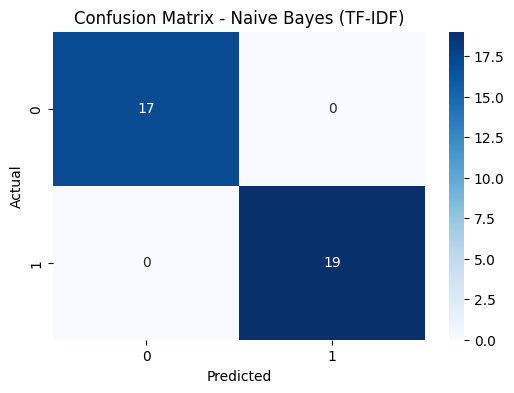

In [19]:
print("=== Naive Bayes (TF-IDF) ===")

y_pred_nb_tfidf = nb_model_tfidf.predict(X_test_tfidf)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_nb_tfidf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_tfidf))

cm_nb_tfidf = confusion_matrix(y_test, y_pred_nb_tfidf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nb_tfidf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Naive Bayes (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Evaluasi Naive Bayes (BoW)

=== Naive Bayes (BoW) ===
Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        17
     positif       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



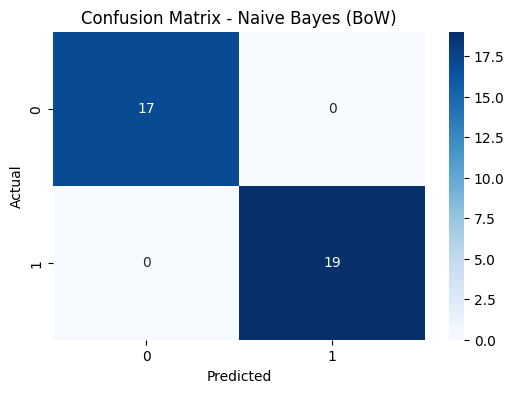

In [20]:
print("=== Naive Bayes (BoW) ===")

y_pred_nb_bow = nb_model_bow.predict(X_test_bow)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_nb_bow))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_bow))

cm_nb_bow = confusion_matrix(y_test, y_pred_nb_bow)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nb_bow,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Naive Bayes (BoW)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Evaluasi Logistic Regression (TF-IDF)

=== Logistic Regression (TF-IDF) ===
Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        17
     positif       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



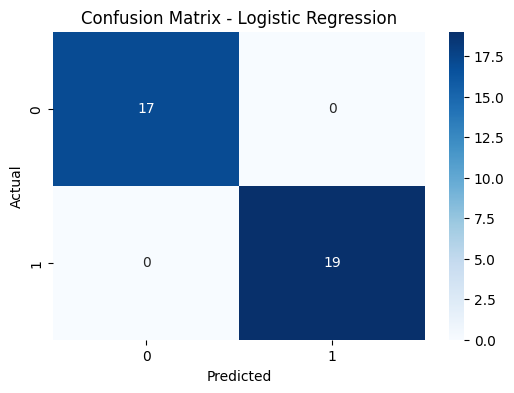

In [21]:
print("=== Logistic Regression (TF-IDF) ===")

y_pred_lr = lr_model_tfidf.predict(X_test_tfidf)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Evaluasi Linear SVM (TF-IDF)

=== Linear SVM (TF-IDF) ===
Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        17
     positif       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



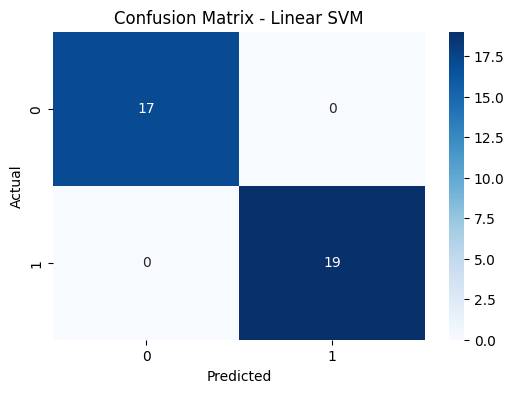

In [22]:
print("=== Linear SVM (TF-IDF) ===")

y_pred_svm = svm_model_tfidf.predict(X_test_tfidf)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## b. Cross Validation

Cross-validation digunakan untuk mendapatkan evaluasi model yang lebih stabil dan mengurangi kemungkinan overfitting. Pada penelitian ini digunakan Stratified K-Fold agar proporsi kelas sentimen tetap seimbang pada setiap fold.

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [24]:
# Encode label
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [25]:
# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
models_for_cv = [
    {
        'name': 'Naive Bayes (TF-IDF)',
        'model': MultinomialNB(),
        'feature_type': 'tfidf'
    },
    {
        'name': 'Logistic Regression (TF-IDF)',
        'model': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        'feature_type': 'tfidf'
    },
    {
        'name': 'Linear SVM (TF-IDF)',
        'model': LinearSVC(
            random_state=42
        ),
        'feature_type': 'tfidf'
    },
    {
        'name': 'Naive Bayes (BoW)',
        'model': MultinomialNB(),
        'feature_type': 'bow'
    }
]

In [27]:
cv_results = []

for config in models_for_cv:

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for train_index, test_index in skf.split(X, y_encoded):

        X_train_fold = X.iloc[train_index]
        X_test_fold = X.iloc[test_index]

        y_train_fold = y.iloc[train_index]
        y_test_fold = y.iloc[test_index]

        # Pilih vectorizer
        if config['feature_type'] == 'tfidf':
            vectorizer = TfidfVectorizer()
        else:
            vectorizer = CountVectorizer()

        # Vectorization
        X_train_vectorized = vectorizer.fit_transform(X_train_fold)
        X_test_vectorized = vectorizer.transform(X_test_fold)

        # Training model
        model = config['model']
        model.fit(X_train_vectorized, y_train_fold)

        # Prediksi
        y_pred = model.predict(X_test_vectorized)

        # Evaluasi
        accuracy_scores.append(
            accuracy_score(y_test_fold, y_pred)
        )

        precision_scores.append(
            precision_score(
                y_test_fold,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )

        recall_scores.append(
            recall_score(
                y_test_fold,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )

        f1_scores.append(
            f1_score(
                y_test_fold,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )

    cv_results.append({
        'Model': config['name'],
        'Accuracy': round(np.mean(accuracy_scores), 4),
        'Precision': round(np.mean(precision_scores), 4),
        'Recall': round(np.mean(recall_scores), 4),
        'F1-Score': round(np.mean(f1_scores), 4)
    })

In [28]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes (TF-IDF),1.0,1.0,1.0,1.0
1,Logistic Regression (TF-IDF),1.0,1.0,1.0,1.0
2,Linear SVM (TF-IDF),1.0,1.0,1.0,1.0
3,Naive Bayes (BoW),1.0,1.0,1.0,1.0


# 10. Prediksi Data Baru

Model yang telah dilatih dapat digunakan untuk memprediksi sentimen pada komentar baru yang belum pernah dilihat sebelumnya.

In [31]:
def preprocess_text(text):
    text = case_folding(text)
    text = cleaning(text)
    tokens = tokenize(text)
    tokens = stopword_removal(tokens)
    tokens = stemming(tokens)
    return ' '.join(tokens)

def predict_sentiment(comment, model, vectorizer):

    # Preprocessing komentar
    processed_comment = preprocess_text(comment)

    # Transform ke vector
    comment_vectorized = vectorizer.transform(
        [processed_comment]
    )

    # Prediksi sentimen
    prediction = model.predict(comment_vectorized)

    return prediction[0]

In [32]:
# Contoh komentar baru
new_comment1 = "Timnas main bagus sekali, sangat bangga!"
new_comment2 = "Permainan hari ini mengecewakan."
new_comment3 = "Hasilnya seri, lumayan lah."

print("=== Prediksi Komentar Baru ===")

print(f"\nKomentar: {new_comment1}")

print(
    "Naive Bayes:",
    predict_sentiment(
        new_comment1,
        nb_model_tfidf,
        tfidf_vectorizer
    )
)

print(
    "Logistic Regression:",
    predict_sentiment(
        new_comment1,
        lr_model_tfidf,
        tfidf_vectorizer
    )
)

print(
    "Linear SVM:",
    predict_sentiment(
        new_comment1,
        svm_model_tfidf,
        tfidf_vectorizer
    )
)

print("\n-------------------")

print(f"\nKomentar: {new_comment2}")

print(
    "Naive Bayes:",
    predict_sentiment(
        new_comment2,
        nb_model_tfidf,
        tfidf_vectorizer
    )
)

print(
    "Logistic Regression:",
    predict_sentiment(
        new_comment2,
        lr_model_tfidf,
        tfidf_vectorizer
    )
)

print(
    "Linear SVM:",
    predict_sentiment(
        new_comment2,
        svm_model_tfidf,
        tfidf_vectorizer
    )
)

=== Prediksi Komentar Baru ===

Komentar: Timnas main bagus sekali, sangat bangga!
Naive Bayes: positif
Logistic Regression: positif
Linear SVM: positif

-------------------

Komentar: Permainan hari ini mengecewakan.
Naive Bayes: negatif
Logistic Regression: negatif
Linear SVM: negatif


# 11. Analisis Hasil

### a. Distribusi Sentimen

Visualisasi ini menunjukkan proporsi sentimen positif dan negatif dalam dataset, memberikan gambaran umum tentang polaritas komentar yang dikumpulkan.

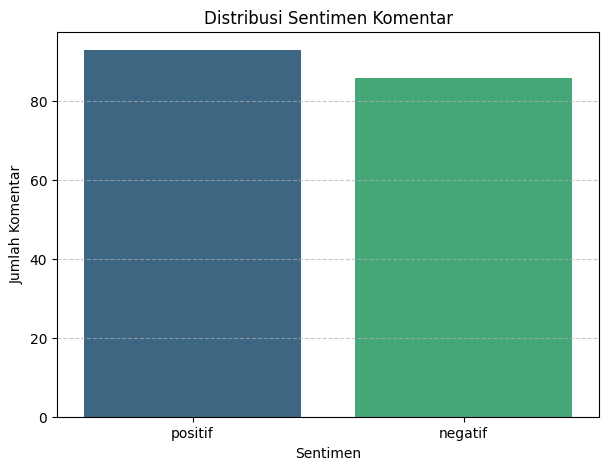

In [33]:
# Grafik distribusi sentimen
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribusi Sentimen Komentar')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### b. Wordcloud Sentimen Positif dan Negatif

*Wordcloud* adalah representasi visual dari kata-kata yang paling sering muncul dalam teks. Ukuran kata menunjukkan frekuensinya. Ini membantu dalam mengidentifikasi kata-kata kunci yang terkait dengan sentimen positif dan negatif.

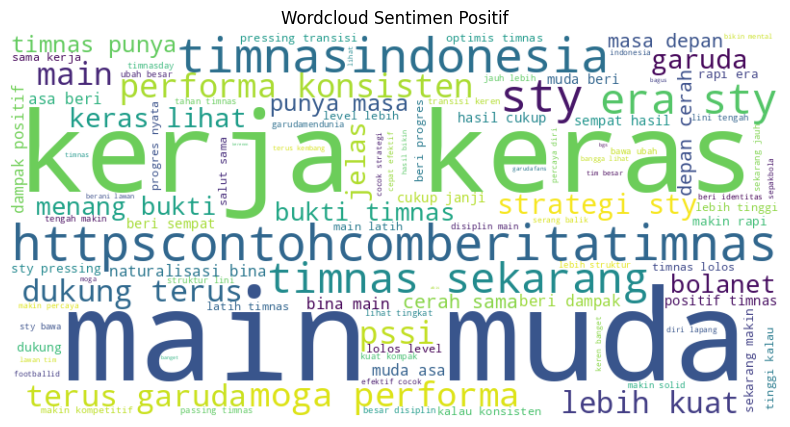

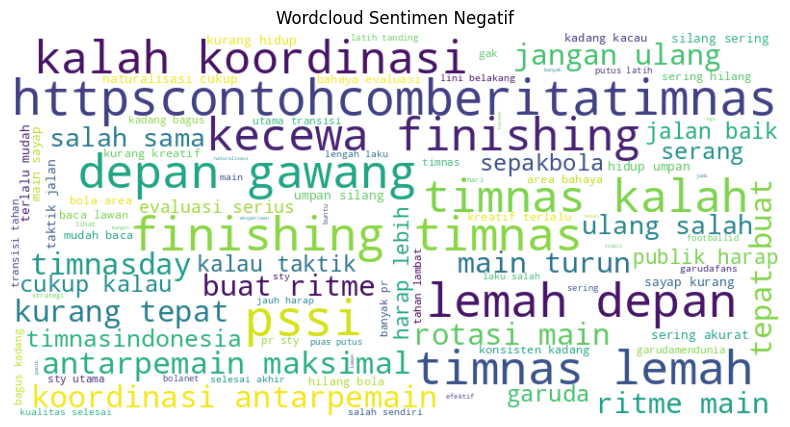

In [34]:
# Gabungkan semua komentar positif yang sudah diproses
positive_comments = ' '.join(df[df['sentiment'] == 'positif']['komentar_preprocessed'])

# Gabungkan semua komentar negatif yang sudah diproses
negative_comments = ' '.join(df[df['sentiment'] == 'negatif']['komentar_preprocessed'])

# Fungsi untuk membuat wordcloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Wordcloud untuk sentimen positif
create_wordcloud(positive_comments, 'Wordcloud Sentimen Positif')

# Wordcloud untuk sentimen negatif
create_wordcloud(negative_comments, 'Wordcloud Sentimen Negatif')

### c. Top 10 Kata yang Paling Sering Muncul dan Analisis Kata Dominan

Analisis ini mengidentifikasi 10 kata teratas yang muncul dalam setiap kategori sentimen setelah pra-pemrosesan. Ini membantu dalam memahami konteks dan nuansa bahasa yang digunakan dalam komentar positif dan negatif.

Top 10 Kata dalam Sentimen Positif:
- timnas: 74
- main: 54
- sty: 50
- beri: 28
- makin: 25
- lihat: 23
- lebih: 23
- terus: 22
- muda: 21
- garuda: 20


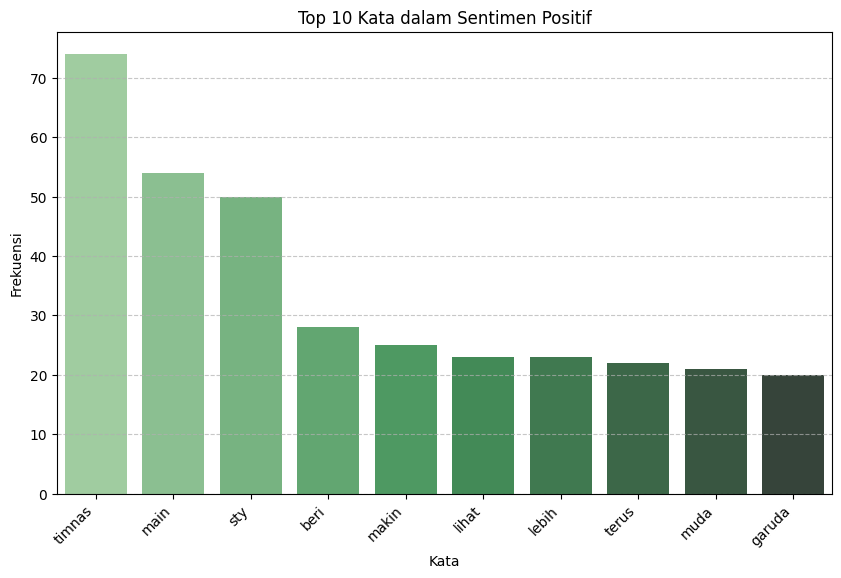



Top 10 Kata dalam Sentimen Negatif:
- main: 41
- timnas: 40
- kurang: 29
- sering: 23
- sty: 14
- salah: 14
- httpscontohcomberitatimnas: 13
- evaluasi: 13
- pssi: 13
- kecewa: 12


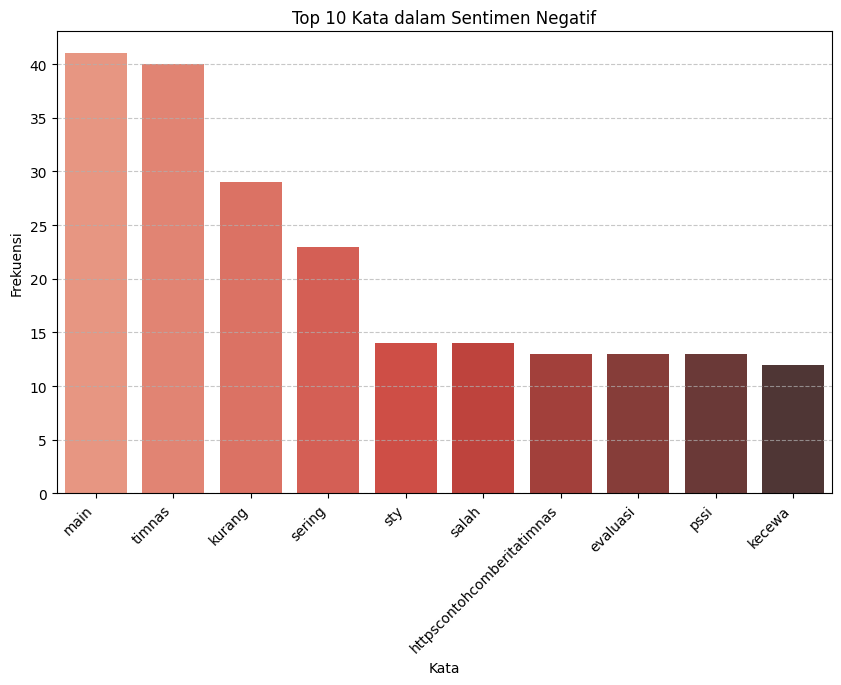

In [35]:
# Fungsi untuk mendapatkan top N kata
def get_top_n_words(corpus, n=10):
    words = corpus.split()
    counter = Counter(words)
    most_common = counter.most_common(n)
    return most_common

# Top 10 kata untuk sentimen positif
top_positive_words = get_top_n_words(positive_comments, 10)
print("Top 10 Kata dalam Sentimen Positif:")
for word, count in top_positive_words:
    print(f"- {word}: {count}")

# Visualisasi top 10 kata positif
words_pos, counts_pos = zip(*top_positive_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(words_pos), y=list(counts_pos), palette='Greens_d', hue=list(words_pos), legend=False)
plt.title('Top 10 Kata dalam Sentimen Positif')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n" + "="*40 + "\n")

# Top 10 kata untuk sentimen negatif
top_negative_words = get_top_n_words(negative_comments, 10)
print("Top 10 Kata dalam Sentimen Negatif:")
for word, count in top_negative_words:
    print(f"- {word}: {count}")

# Visualisasi top 10 kata negatif
words_neg, counts_neg = zip(*top_negative_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(words_neg), y=list(counts_neg), palette='Reds_d', hue=list(words_neg), legend=False)
plt.title('Top 10 Kata dalam Sentimen Negatif')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### d. Perbandingan Performa Model Machine Learning

Bagian ini menampilkan perbandingan performa model machine learning berdasarkan hasil cross-validation menggunakan accuracy dan F1-score.

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes (TF-IDF),1.0,1.0,1.0,1.0
1,Logistic Regression (TF-IDF),1.0,1.0,1.0,1.0
2,Linear SVM (TF-IDF),1.0,1.0,1.0,1.0
3,Naive Bayes (BoW),1.0,1.0,1.0,1.0


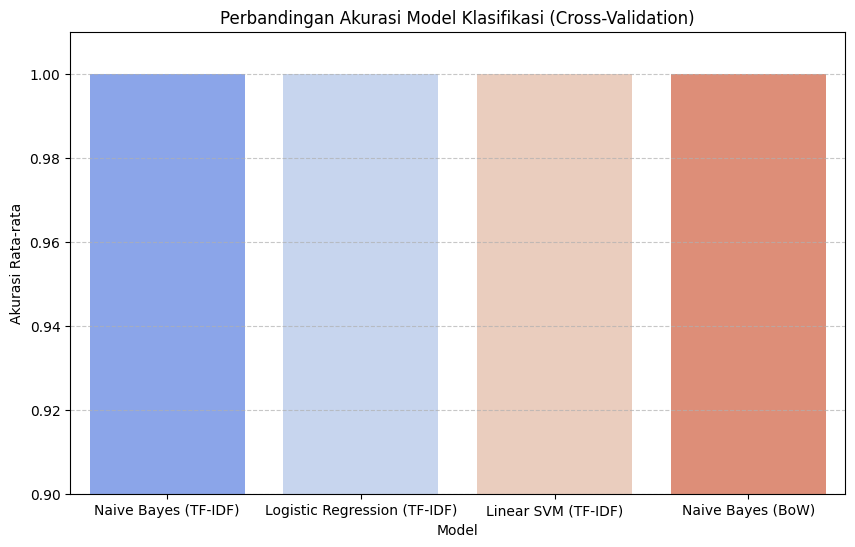

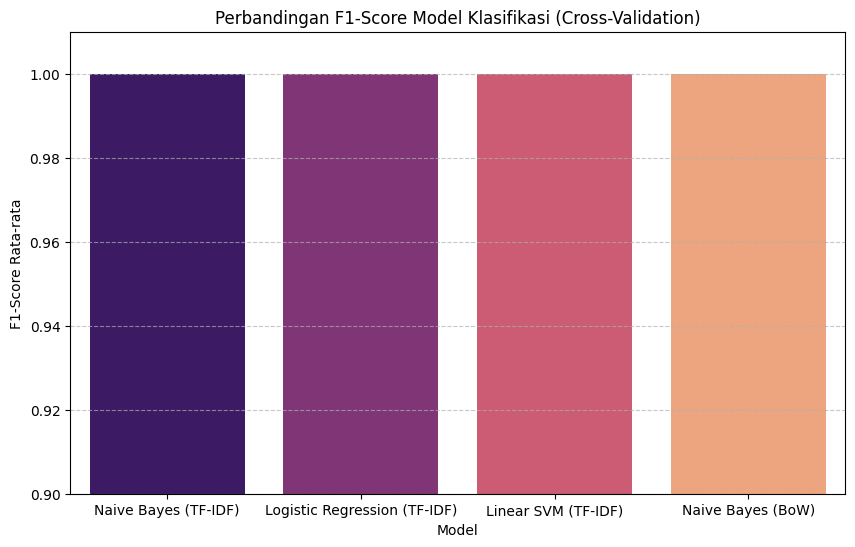

In [37]:
# Data performa dari hasil cross-validation, diambil dari dictionary yang telah diisi
# model_performance = {
#     'Model': all_model_avg_scores['Model'],
#     'Accuracy': all_model_avg_scores['Accuracy'],
#     'Precision': all_model_avg_scores['Precision'],
#     'Recall': all_model_avg_scores['Recall'],
#     'F1-Score': all_model_avg_scores['F1-Score']
# }

df_performance = cv_results_df
display(df_performance)

# Visualisasi perbandingan akurasi model
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_performance, palette='coolwarm', hue='Model', legend=False)
plt.title('Perbandingan Akurasi Model Klasifikasi (Cross-Validation)')
plt.xlabel('Model')
plt.ylabel('Akurasi Rata-rata')
plt.ylim(0.9, 1.01) # Batasi y-axis untuk fokus pada perbedaan
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualisasi perbandingan F1-Score model
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=df_performance, palette='magma', hue='Model', legend=False)
plt.title('Perbandingan F1-Score Model Klasifikasi (Cross-Validation)')
plt.xlabel('Model')
plt.ylabel('F1-Score Rata-rata')
plt.ylim(0.9, 1.01) # Batasi y-axis untuk fokus pada perbedaan
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### e. Kesimpulan Analisis

Berdasarkan hasil analisis, seluruh model machine learning menghasilkan performa yang sangat tinggi dengan nilai akurasi mencapai 1.00. Hal ini kemungkinan dipengaruhi oleh ukuran dataset yang relatif kecil dan pola sentimen yang cukup jelas sehingga model lebih mudah membedakan komentar positif dan negatif.

Visualisasi wordcloud menunjukkan bahwa sentimen positif didominasi kata-kata seperti “bagus”, “menang”, dan “bangga”, sedangkan sentimen negatif didominasi kata seperti “buruk”, “lemah”, dan “kecewa”. Selain itu, hasil cross-validation menunjukkan bahwa model memiliki performa yang stabil pada setiap fold pengujian.